# Modèle de Deep Learning : ResNet_50

Les modèles de deep learning sont entraînés directement à partir des images.

Afin de garantir une comparaison équitable avec les autres modèles de deep
learning du projet, les mêmes jeux de données sont utilisés :

- `train_augmented` pour l’entraînement ;
- `validation` pour la validation ;
- `test` pour l’évaluation finale.

Aucune nouvelle augmentation d’images ne sera appliquée dans le modèle,
puisque le jeu `train_augmented` contient déjà les images augmentées communes
aux différents modèles.

L'intégrité des données à été vérifiée dans le notebook du modèle `ResNet50` avec correction du déséquilibre.

Aucune correction supplémentaire de poids n'est réalisée ici.

# Préparation

## Environnement de travail

In [2]:
# Imports et configuration générale

from pathlib import Path
import os
import random
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Graine utilisée pour améliorer la reproductibilité
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Imports réalisés avec succès.")
print("Seed :", SEED)

I0000 00:00:1784458652.790862  937566 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784458652.954106  937566 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784458655.521038  937566 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Imports réalisés avec succès.
Seed : 42


In [3]:
# Vérification gpu

print("=" * 70)
print("Python :", sys.executable)
print("TensorFlow :", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if not gpus:
    raise RuntimeError(
        "Aucun GPU détecté. Vérifie que le kernel sélectionné est "
        "'Python (Covid19_gpu)'."
    )

print("GPU détecté(s) :", gpus)

for gpu in gpus:
    details = tf.config.experimental.get_device_details(gpu)
    print(
        "Nom du GPU :",
        details.get("device_name", gpu.name)
    )

print("=" * 70)

Python : /home/noura/miniforge3/envs/Covid19_gpu/bin/python
TensorFlow : 2.21.0
GPU détecté(s) : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Nom du GPU : NVIDIA GeForce RTX 4090 Laptop GPU


In [4]:
# Allocation progressive de la mémoire GPU

gpus = tf.config.list_physical_devices("GPU")

for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as error:
        print(
            "La mémoire GPU a déjà été initialisée :",
            error
        )

print("Allocation progressive de la mémoire GPU configurée.")

Allocation progressive de la mémoire GPU configurée.


## Définition des chemins vers les jeux d’images

Les modèles de deep learning utilisent directement les images.

Pour garantir une comparaison équitable avec les autres modèles de l’équipe,
les jeux suivants sont utilisés :

- `train_augmented` pour l’entraînement ;
- `validation` pour la validation ;
- `test` pour l’évaluation finale.

Les chemins sont écrits au format WSL, le disque Windows `C:` étant accessible
depuis Ubuntu sous `/mnt/c/`.

In [5]:
# Dossier principal contenant les jeux d'images
DATASET_DIR = Path(
    "/mnt/c/Users/n_a_e/Documents/DataScientest/"
    "Data Scientist/Projet COVID/"
    "COVID-19_Radiography_Dataset_split"
)

# Dossiers utilisés pour ResNet
TRAIN_DIR = DATASET_DIR / "train_augmented"
VAL_DIR = DATASET_DIR / "validation"
TEST_DIR = DATASET_DIR / "test"

dataset_paths = {
    "Entraînement": TRAIN_DIR,
    "Validation": VAL_DIR,
    "Test": TEST_DIR
}

print("Dossier principal :", DATASET_DIR)
print()

for dataset_name, dataset_path in dataset_paths.items():
    print(f"{dataset_name} :")
    print(f"  Chemin : {dataset_path}")
    print(f"  Existe : {dataset_path.exists()}")
    print()

Dossier principal : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/COVID-19_Radiography_Dataset_split

Entraînement :
  Chemin : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/COVID-19_Radiography_Dataset_split/train_augmented
  Existe : True

Validation :
  Chemin : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/COVID-19_Radiography_Dataset_split/validation
  Existe : True

Test :
  Chemin : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/COVID-19_Radiography_Dataset_split/test
  Existe : True



In [6]:
missing_directories = [
    str(dataset_path)
    for dataset_path in dataset_paths.values()
    if not dataset_path.exists()
]

if missing_directories:
    raise FileNotFoundError(
        "Les dossiers suivants sont introuvables :\n"
        + "\n".join(missing_directories)
    )

print("Les trois dossiers ont été trouvés avec succès.")

Les trois dossiers ont été trouvés avec succès.


# Préparation des données

In [7]:
# Définition de l'ordre des classes

class_names = [
    "COVID",
    "Lung_Opacity",
    "Normal",
    "Viral Pneumonia"
]

NUM_CLASSES = len(class_names)

print("Classes utilisées :", class_names)

Classes utilisées : ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']


## Paramètres de chargement des images

Les images seront redimensionnées au format attendu par ResNet.

Les paramètres suivants sont communs aux jeux d’entraînement, de validation et de test afin de garantir une comparaison cohérente.

In [8]:
# Dimensions d'entrée du modèle
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)

# Taille des lots
BATCH_SIZE = 32

# Nombre de classes détectées précédemment
NUM_CLASSES = len(class_names)

print("Dimensions des images :", IMG_SIZE)
print("Taille des batchs :", BATCH_SIZE)
print("Nombre de classes :", NUM_CLASSES)

Dimensions des images : (224, 224)
Taille des batchs : 32
Nombre de classes : 4


## Création des jeux de données TensorFlow

Le jeu d’entraînement est chargé depuis le dossier `train_augmented`.

Les labels sont encodés sous forme d’entiers, ce qui permettra d’utiliser la fonction de perte `sparse_categorical_crossentropy`.

Les jeux de validation et de test sont créés avec les mêmes paramètres que le jeu d'entraînement.

Contrairement au jeu d'entraînement, les images ne sont pas mélangées (`shuffle=False`) afin de garantir un ordre stable des échantillons lors de l'évaluation finale et du calcul de la matrice de confusion.

In [36]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 33336 files belonging to 4 classes.
Found 2083 files belonging to 4 classes.
Found 2084 files belonging to 4 classes.


## Vérification d’un batch TensorFlow

Cette étape permet de contrôler la forme des tenseurs, le type des données,
la plage des valeurs de pixels et la correspondance entre les images et leurs labels.

In [17]:
images_batch, labels_batch = next(iter(train_ds))

print("Images :", images_batch.shape)
print("Labels :", labels_batch.shape)
print("Pixels :", tf.reduce_min(images_batch).numpy(),
      tf.reduce_max(images_batch).numpy())

Images : (32, 224, 224, 3)
Labels : (32,)
Pixels : -123.221756 151.061


W0000 00:00:1784459075.625956  937566 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


In [18]:
print("Correspondance des labels :")
print()

for class_index, class_name in enumerate(class_names):
    print(f"{class_index} -> {class_name}")

Correspondance des labels :

0 -> COVID
1 -> Lung_Opacity
2 -> Normal
3 -> Viral Pneumonia


## Optimisation du pipeline TensorFlow

Avant l'entraînement, les jeux de données sont optimisés afin d'améliorer les performances :

- application du prétraitement officiel de ResNet50 ;
- mise en cache des données (`cache()`) ;
- préchargement asynchrone (`prefetch()`).

Ces optimisations réduisent le temps d'entraînement sans modifier les données.

In [14]:
# Import du prétraitement

from tensorflow.keras.applications.resnet50 import preprocess_input

AUTOTUNE = tf.data.AUTOTUNE

In [19]:
#Fonction de prétraitement

def preprocess(image, label):
    """
    Prétraitement officiel de ResNet50.

    Les images passent d'un intervalle [0 ; 255]
    au format attendu par ResNet50.
    """
    image = preprocess_input(image)

    return image, label

In [37]:
#Pipeline optimisé

train_ds = (
    train_ds
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

print("Pipeline TensorFlow optimisé avec succès.")

Pipeline TensorFlow optimisé avec succès.


In [38]:
# Vérification

images, labels = next(iter(train_ds))

print(images.shape)
print(labels.shape)
print(
    "Pixels après preprocess :",
    tf.reduce_min(images).numpy(),
    tf.reduce_max(images).numpy()
)

(32, 224, 224, 3)
(32,)
Pixels après preprocess : -122.68 151.061


# Modélisation

## Construction du modèle ResNet50

Un modèle ResNet50 pré-entraîné sur ImageNet est utilisé comme extracteur de caractéristiques.

Dans un premier temps, les couches convolutives sont gelées. Seule une nouvelle tête de classification adaptée aux quatre classes du projet sera entraînée.

In [21]:
# Téléchargement

from tensorflow.keras.applications import ResNet50

# Chargement de ResNet50 sans sa couche de classification d'origine
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# Gel de toutes les couches pré-entraînées
base_model.trainable = False

print("ResNet50 chargé avec succès.")
print("Nombre total de couches :", len(base_model.layers))
print("Modèle de base entraînable :", base_model.trainable)

ResNet50 chargé avec succès.
Nombre total de couches : 175
Modèle de base entraînable : False


In [22]:
# Construction de la tête de classification

inputs = keras.Input(
    shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    name="input_image"
)

# Passage dans ResNet50
x = base_model(
    inputs,
    training=False
)

# Réduction de chaque carte de caractéristiques à une valeur moyenne
x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

# Régularisation afin de limiter le surapprentissage
x = layers.Dropout(
    0.4,
    name="dropout"
)(x)

# Classification finale sur les quatre classes
outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="classification"
)(x)

model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="ResNet50_COVID19"
)

print("Modèle complet construit avec succès.")

Modèle complet construit avec succès.


In [23]:
# Vérification du modèle

model.summary()

Model: "ResNet50_COVID19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification (Dense)          │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,595,908 (90.01 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [24]:
trainable_params = sum(
    np.prod(variable.shape)
    for variable in model.trainable_weights
)

non_trainable_params = sum(
    np.prod(variable.shape)
    for variable in model.non_trainable_weights
)

print(f"Paramètres entraînables     : {trainable_params:,}")
print(f"Paramètres non entraînables : {non_trainable_params:,}")

Paramètres entraînables     : 8,196
Paramètres non entraînables : 23,587,712


## Code de rechargement des modèles si besoin

Code_1

Dossier principal du projet au format WSL
PROJECT_DIR = Path(
    "/mnt/c/Users/n_a_e/Documents/DataScientest/"
    "Data Scientist/Projet COVID"
)

Dossier contenant les modèles sauvegardés
OUTPUT_DIR = PROJECT_DIR / "outputs_resnet50_sans_class_weight"

Meilleur modèle obtenu après la phase 1
PHASE1_MODEL_PATH = (
    OUTPUT_DIR / "resnet50_phase1_sans_class_weight_best.keras"
)

Vérification de l'existence du fichier
if not PHASE1_MODEL_PATH.exists():
    raise FileNotFoundError(
        "Le modèle de phase 1 est introuvable :\n"
        f"{PHASE1_MODEL_PATH}"
    )

Chargement du modèle complet
model = keras.models.load_model(
    PHASE1_MODEL_PATH
)

print("✅ Modèle de phase 1 chargé avec succès.")
print("Nom du modèle :", model.name)
print("Chemin :", PHASE1_MODEL_PATH)

Code_2

Récupération du modèle ResNet50 imbriqué
base_model = model.get_layer("resnet50")

print("Modèle de base :", base_model.name)
print("Nombre de couches :", len(base_model.layers))
print("Entraînable :", base_model.trainable)


## Phase 1 : Transfer Learning

### Compilation du modèle — Phase 1

Dans cette première phase, le réseau ResNet50 reste entièrement gelé.

Seule la nouvelle couche de classification est entraînée avec :

- l’optimiseur Adam ;
- un taux d’apprentissage de `1e-4` ;
- la fonction de perte `SparseCategoricalCrossentropy`, adaptée aux labels entiers ;
- l’accuracy comme métrique de suivi.

Des callbacks permettent de sauvegarder le meilleur modèle, de réduire le taux
d’apprentissage en cas de stagnation et d’arrêter l’entraînement avant le
surapprentissage.

In [ ]:
# Dossier principal du projet au format WSL
PROJECT_DIR = Path(
    "/mnt/c/Users/n_a_e/Documents/DataScientest/"
    "Data Scientist/Projet COVID"
)

# Dossier contenant les résultats sans class_weight
OUTPUT_DIR = (
    PROJECT_DIR
    / "outputs_resnet50_sans_class_weight"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Modèles sauvegardés
PHASE1_MODEL_PATH = (
    OUTPUT_DIR
    / "resnet50_phase1_sans_class_weight_best.keras"
)

PHASE2_MODEL_PATH = (
    OUTPUT_DIR
    / "resnet50_finetuning_sans_class_weight_best.keras"
)

print("Dossier du projet :", PROJECT_DIR)
print("Dossier de sortie :", OUTPUT_DIR)
print("Modèle phase 1    :", PHASE1_MODEL_PATH)
print("Modèle fine-tuné  :", PHASE2_MODEL_PATH)

Dossier de sortie : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/Liora_Covid/notebooks/Modelisation/ResNet/outputs_resnet50_sans_class_weight


In [ ]:
print("\nVérification des fichiers existants :")
print(
    "Modèle phase 1 trouvé :",
    PHASE1_MODEL_PATH.exists()
)
print(
    "Modèle fine-tuné trouvé :",
    PHASE2_MODEL_PATH.exists()
)

In [31]:
# Compilation

LEARNING_RATE_PHASE1 = 1e-4

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE_PHASE1
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("Modèle compilé avec succès.")
print("Learning rate phase 1 :", LEARNING_RATE_PHASE1)

Modèle compilé avec succès.
Learning rate phase 1 : 0.0001


In [32]:
# définition des callbacks

callbacks_phase1 = [
    keras.callbacks.ModelCheckpoint(
        filepath=PHASE1_MODEL_PATH,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks configurés :", len(callbacks_phase1))

for callback in callbacks_phase1:
    print("-", callback.__class__.__name__)

Callbacks configurés : 3
- ModelCheckpoint
- EarlyStopping
- ReduceLROnPlateau


In [35]:
images, labels = next(iter(train_ds))

print(images.shape)
print(labels.shape)

(32, 224, 224, 3)
(32,)


W0000 00:00:1784459756.402322  937566 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
W0000 00:00:1784459756.402442  937566 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


### Entraînement de la tête de classification

Dans cette première phase, toutes les couches de ResNet50 restent gelées.

Seule la tête de classification ajoutée au modèle est entraînée pendant un maximum de 20 époques. Les poids de classes sont utilisés afin de limiter l’impact du déséquilibre entre les catégories.

In [39]:
EPOCHS_PHASE1 = 20

history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks_phase1
)

Epoch 1/20
1041/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.6125 - loss: 1.0107

I0000 00:00:1784460154.914914  939084 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_11007__.181


1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.6126 - loss: 1.0107

W0000 00:00:1784460165.150207  937566 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
W0000 00:00:1784460165.150484  937566 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.



Epoch 1: val_loss improved from None to 0.62561, saving model to /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/Liora_Covid/notebooks/Modelisation/ResNet/outputs_resnet50_sans_class_weight/resnet50_phase1_sans_class_weight_best.keras

Epoch 1: finished saving model to /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/Liora_Covid/notebooks/Modelisation/ResNet/outputs_resnet50_sans_class_weight/resnet50_phase1_sans_class_weight_best.keras
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 132s 126ms/step - accuracy: 0.6126 - loss: 1.0107 - val_accuracy: 0.7528 - val_loss: 0.6256 - learning_rate: 1.0000e-04
Epoch 2/20
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.7226 - loss: 0.7096
Epoch 2: val_loss improved from 0.62561 to 0.55539, saving model to /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/Liora_Covid/notebooks/Modelisation/ResNet/outputs_resnet50_sans_class_weight/resnet50_phase1_sans_class_weight_best.keras

Epoch 2: f

In [40]:
epochs_completed_phase1 = len(history_phase1.history["loss"])

best_epoch_phase1 = (
    np.argmin(history_phase1.history["val_loss"]) + 1
)

best_val_loss_phase1 = np.min(
    history_phase1.history["val_loss"]
)

best_val_accuracy_phase1 = history_phase1.history[
    "val_accuracy"
][best_epoch_phase1 - 1]

print("Phase 1 terminée.")
print("Nombre d'époques exécutées :", epochs_completed_phase1)
print("Meilleure époque :", best_epoch_phase1)
print(f"Meilleure val_loss : {best_val_loss_phase1:.4f}")
print(
    f"Val_accuracy à la meilleure époque : "
    f"{best_val_accuracy_phase1:.4f}"
)
print("Modèle sauvegardé dans :", PHASE1_MODEL_PATH)

Phase 1 terminée.
Nombre d'époques exécutées : 20
Meilleure époque : 20
Meilleure val_loss : 0.4480
Val_accuracy à la meilleure époque : 0.8272
Modèle sauvegardé dans : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/Liora_Covid/notebooks/Modelisation/ResNet/outputs_resnet50_sans_class_weight/resnet50_phase1_sans_class_weight_best.keras


### Analyse de l’entraînement de la phase 1

Les courbes de perte et d’accuracy permettent d’évaluer la convergence du modèle
et de détecter un éventuel surapprentissage avant le fine-tuning.

In [41]:
history_phase1_df = pd.DataFrame(
    history_phase1.history
)

history_phase1_df.index = np.arange(
    1,
    len(history_phase1_df) + 1
)

history_phase1_df.index.name = "Époque"

history_phase1_df

,accuracy,loss,val_accuracy,val_loss,learning_rate
Époque,,,,,
1,0.612551,1.010740,0.752760,0.625608,0.0001
2,0.722642,0.709621,0.771483,0.555391,0.0001
3,0.754230,0.628437,0.785886,0.527478,0.0001
4,0.768449,0.592974,0.795487,0.511036,0.0001
5,0.779008,0.566967,0.794527,0.506017,0.0001
6,0.786627,0.549916,0.806049,0.489706,0.0001
7,0.789357,0.540987,0.807009,0.486290,0.0001
8,0.795536,0.531506,0.806049,0.480382,0.0001
9,0.796376,0.525274,0.810370,0.474243,0.0001


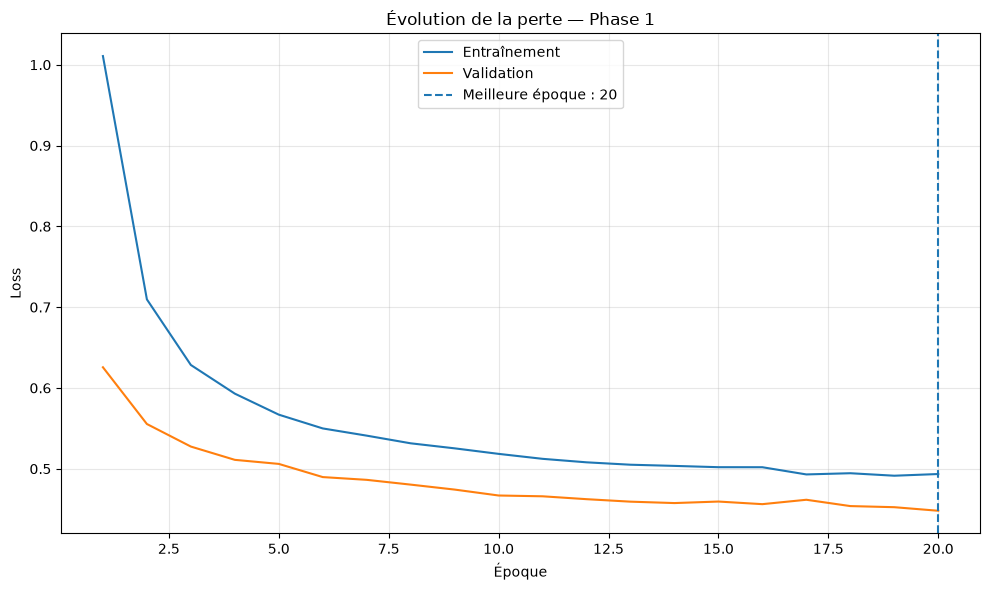

In [42]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_phase1_df.index,
    history_phase1_df["loss"],
    label="Entraînement"
)

plt.plot(
    history_phase1_df.index,
    history_phase1_df["val_loss"],
    label="Validation"
)

plt.axvline(
    best_epoch_phase1,
    linestyle="--",
    label=f"Meilleure époque : {best_epoch_phase1}"
)

plt.title("Évolution de la perte — Phase 1")
plt.xlabel("Époque")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

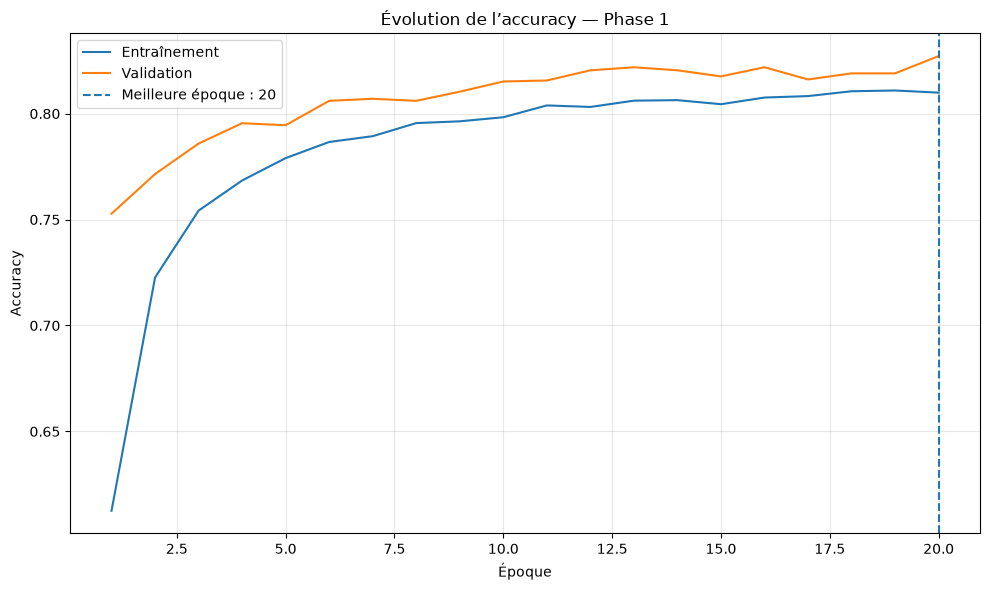

In [43]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_phase1_df.index,
    history_phase1_df["accuracy"],
    label="Entraînement"
)

plt.plot(
    history_phase1_df.index,
    history_phase1_df["val_accuracy"],
    label="Validation"
)

plt.axvline(
    best_epoch_phase1,
    linestyle="--",
    label=f"Meilleure époque : {best_epoch_phase1}"
)

plt.title("Évolution de l’accuracy — Phase 1")
plt.xlabel("Époque")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [44]:
final_train_loss = history_phase1_df["loss"].iloc[-1]
final_val_loss = history_phase1_df["val_loss"].iloc[-1]

final_train_accuracy = history_phase1_df[
    "accuracy"
].iloc[-1]

final_val_accuracy = history_phase1_df[
    "val_accuracy"
].iloc[-1]

print("Dernière époque exécutée :")
print(f"Train loss     : {final_train_loss:.4f}")
print(f"Validation loss: {final_val_loss:.4f}")
print()
print(f"Train accuracy     : {final_train_accuracy:.4f}")
print(f"Validation accuracy: {final_val_accuracy:.4f}")
print()
print(
    "Écart d'accuracy train-validation : "
    f"{final_train_accuracy - final_val_accuracy:.4f}"
)

Dernière époque exécutée :
Train loss     : 0.4935
Validation loss: 0.4480

Train accuracy     : 0.8099
Validation accuracy: 0.8272

Écart d'accuracy train-validation : -0.0173


### Évaluation du modèle après phase 1 sur le jeu de test

Avant le fine-tuning, le modèle obtenu à l'issue de la phase 1 est évalué
sur le jeu de test indépendant.

Cette évaluation servira de référence (baseline) pour comparer les
performances obtenues après le fine-tuning.

Les métriques calculées sont :

- Accuracy
- Balanced Accuracy
- Precision (macro)
- Recall (macro)
- F1-score (macro)
- Matrice de confusion
- Rapport de classification

In [45]:
# Chargement du meilleur modèle

best_model_phase1 = keras.models.load_model(
    PHASE1_MODEL_PATH
)

print("Meilleur modèle chargé.")

Meilleur modèle chargé.


In [46]:
# Prédiction

y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:

    probabilities = best_model_phase1.predict(
        images,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predictions)
    y_prob.extend(probabilities)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("Nombre d'images évaluées :", len(y_true))

Nombre d'images évaluées : 2084


In [47]:
# Calcul des métriques

accuracy = accuracy_score(
    y_true,
    y_pred
)

balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="macro"
)

recall = recall_score(
    y_true,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

results_phase1 = pd.DataFrame({
    "Métrique": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision macro",
        "Recall macro",
        "F1 macro"
    ],
    "Valeur": [
        accuracy,
        balanced_accuracy,
        precision,
        recall,
        f1
    ]
})

results_phase1

,Métrique,Valeur
0,Accuracy,0.818618
1,Balanced Accuracy,0.793539
2,Precision macro,0.817244
3,Recall macro,0.793539
4,F1 macro,0.803245


In [48]:
# Rapport de classification
print("Rapport - Phase 1:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)


Rapport - Phase 1:
                 precision    recall  f1-score   support

          COVID     0.6955    0.5964    0.6422       337
   Lung_Opacity     0.8284    0.7412    0.7824       599
         Normal     0.8347    0.9260    0.8780      1014
Viral Pneumonia     0.9104    0.9104    0.9104       134

       accuracy                         0.8186      2084
      macro avg     0.8172    0.7935    0.8032      2084
   weighted avg     0.8152    0.8186    0.8145      2084



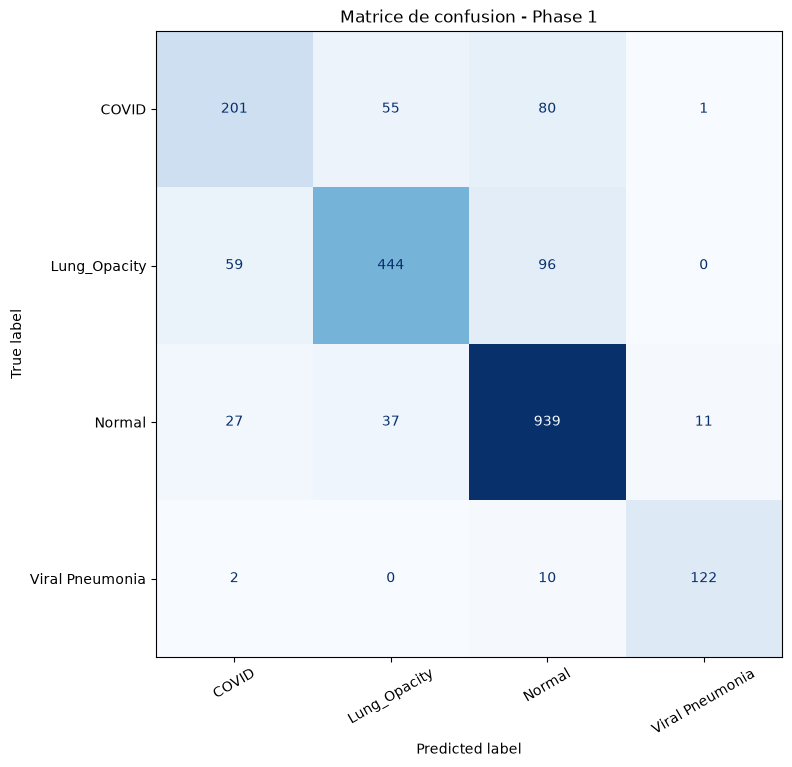

In [49]:
# Matrice de confusion

cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Matrice de confusion - Phase 1")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

## Phase 2 : Fine Tuning

### Péparation du fine-tuning

Le fine-tuning est réalisé uniquement sur le dernier groupe de blocs résiduels
de ResNet50, appelé `conv5_x`.

Cette stratégie permet d’adapter les caractéristiques de haut niveau au domaine
des radiographies thoraciques tout en conservant les représentations génériques
apprises dans les couches précédentes.

In [50]:
# Affichage des 50 dernières couches de ResNet50

start_index = max(0, len(base_model.layers) - 50)

for index in range(start_index, len(base_model.layers)):
    layer = base_model.layers[index]

    print(
        f"{index:>3} | "
        f"{layer.name:<35} | "
        f"{layer.__class__.__name__}"
    )

125 | conv4_block5_1_relu                 | Activation
126 | conv4_block5_2_conv                 | Conv2D
127 | conv4_block5_2_bn                   | BatchNormalization
128 | conv4_block5_2_relu                 | Activation
129 | conv4_block5_3_conv                 | Conv2D
130 | conv4_block5_3_bn                   | BatchNormalization
131 | conv4_block5_add                    | Add
132 | conv4_block5_out                    | Activation
133 | conv4_block6_1_conv                 | Conv2D
134 | conv4_block6_1_bn                   | BatchNormalization
135 | conv4_block6_1_relu                 | Activation
136 | conv4_block6_2_conv                 | Conv2D
137 | conv4_block6_2_bn                   | BatchNormalization
138 | conv4_block6_2_relu                 | Activation
139 | conv4_block6_3_conv                 | Conv2D
140 | conv4_block6_3_bn                   | BatchNormalization
141 | conv4_block6_add                    | Add
142 | conv4_block6_out                    | Activation
143 

In [51]:
# Recherche automatique du début de conv5_x

conv5_start_index = next(
    index
    for index, layer in enumerate(base_model.layers)
    if layer.name.startswith("conv5_block1")
)

print("Indice de début du bloc conv5_x :", conv5_start_index)
print(
    "Première couche du bloc :",
    base_model.layers[conv5_start_index].name
)
print(
    "Nombre de couches dans conv5_x :",
    len(base_model.layers) - conv5_start_index
)

Indice de début du bloc conv5_x : 143
Première couche du bloc : conv5_block1_1_conv
Nombre de couches dans conv5_x : 32


In [52]:
# Vérification de l’état actuel

print("État actuel avant fine-tuning :")
print("Modèle de base entraînable :", base_model.trainable)

trainable_layers_before = sum(
    layer.trainable
    for layer in base_model.layers
)

print(
    "Nombre de couches entraînables dans ResNet50 :",
    trainable_layers_before
)

État actuel avant fine-tuning :
Modèle de base entraînable : False
Nombre de couches entraînables dans ResNet50 : 0


### Déblocage du dernier bloc résiduel

Le modèle de base est rendu entraînable, mais seules les couches appartenant
au bloc `conv5_x` sont dégelées.

Les couches de normalisation par batch restent gelées afin de préserver leurs
statistiques apprises lors du pré-entraînement sur ImageNet.

In [53]:
from tensorflow.keras.layers import BatchNormalization

# Le modèle de base doit être rendu entraînable
base_model.trainable = True

for index, layer in enumerate(base_model.layers):

    # Toutes les couches situées avant conv5_x restent gelées
    if index < conv5_start_index:
        layer.trainable = False

    else:
        # Les couches BatchNormalization restent gelées
        if isinstance(layer, BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True

print("Déblocage contrôlé terminé.")

Déblocage contrôlé terminé.


In [54]:
# Vérification des couches entraînables

trainable_layers = [
    layer.name
    for layer in base_model.layers
    if layer.trainable
]

frozen_layers = [
    layer.name
    for layer in base_model.layers
    if not layer.trainable
]

print("Nombre de couches entraînables dans ResNet50 :", len(trainable_layers))
print("Nombre de couches gelées dans ResNet50       :", len(frozen_layers))

print("\nPremières couches entraînables :")
for layer_name in trainable_layers[:10]:
    print("-", layer_name)

print("\nDernières couches entraînables :")
for layer_name in trainable_layers[-10:]:
    print("-", layer_name)

Nombre de couches entraînables dans ResNet50 : 22
Nombre de couches gelées dans ResNet50       : 153

Premières couches entraînables :
- conv5_block1_1_conv
- conv5_block1_1_relu
- conv5_block1_2_conv
- conv5_block1_2_relu
- conv5_block1_0_conv
- conv5_block1_3_conv
- conv5_block1_add
- conv5_block1_out
- conv5_block2_1_conv
- conv5_block2_1_relu

Dernières couches entraînables :
- conv5_block2_3_conv
- conv5_block2_add
- conv5_block2_out
- conv5_block3_1_conv
- conv5_block3_1_relu
- conv5_block3_2_conv
- conv5_block3_2_relu
- conv5_block3_3_conv
- conv5_block3_add
- conv5_block3_out


In [55]:
# Vérification des paramètres

trainable_params_phase2 = sum(
    np.prod(variable.shape)
    for variable in model.trainable_weights
)

non_trainable_params_phase2 = sum(
    np.prod(variable.shape)
    for variable in model.non_trainable_weights
)

print(f"Paramètres entraînables     : {trainable_params_phase2:,}")
print(f"Paramètres non entraînables : {non_trainable_params_phase2:,}")

Paramètres entraînables     : 14,961,668
Paramètres non entraînables : 8,634,240


### Compilation du modèle pour le fine-tuning

Après le déblocage du dernier bloc résiduel de ResNet50, le modèle est recompilé avec un taux d’apprentissage plus faible.

Cette précaution permet d’adapter progressivement les couches pré-entraînées aux radiographies thoraciques sans modifier brutalement les poids appris sur ImageNet.

In [56]:
LEARNING_RATE_PHASE2 = 1e-5

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE_PHASE2
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("Modèle recompilé pour le fine-tuning.")
print("Learning rate phase 2 :", LEARNING_RATE_PHASE2)

Modèle recompilé pour le fine-tuning.
Learning rate phase 2 : 1e-05


In [57]:
## Callbacks du fine-tuning

PHASE2_MODEL_PATH = (
    OUTPUT_DIR / "resnet50_finetuning_best.keras"
)

callbacks_phase2 = [
    keras.callbacks.ModelCheckpoint(
        filepath=PHASE2_MODEL_PATH,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks phase 2 configurés.")
print("Modèle sauvegardé dans :", PHASE2_MODEL_PATH)

Callbacks phase 2 configurés.
Modèle sauvegardé dans : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/Liora_Covid/notebooks/Modelisation/ResNet/outputs_resnet50_sans_class_weight/resnet50_finetuning_best.keras


In [58]:
# Vérification avant entraînement

print("État du modèle avant fine-tuning")
print("-" * 50)

print("Modèle de base entraînable :", base_model.trainable)

print(
    "Couches entraînables dans ResNet50 :",
    sum(layer.trainable for layer in base_model.layers)
)

print(
    "Paramètres entraînables du modèle complet :",
    f"{sum(np.prod(v.shape) for v in model.trainable_weights):,}"
)

print("Learning rate :", float(model.optimizer.learning_rate.numpy()))

État du modèle avant fine-tuning
--------------------------------------------------
Modèle de base entraînable : True
Couches entraînables dans ResNet50 : 22
Paramètres entraînables du modèle complet : 14,961,668
Learning rate : 9.999999747378752e-06


### Fine-tuning du modèle

Après l'entraînement de la tête de classification, les couches du bloc
`conv5_x` sont réentraînées avec un faible taux d'apprentissage (`1e-5`).

Cette seconde phase permet d'adapter les caractéristiques de haut niveau
du réseau ResNet50 au domaine des radiographies thoraciques.

In [59]:
EPOCHS_PHASE2 = 15

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE2,
    callbacks=callbacks_phase2
)

Epoch 1/15


/home/noura/miniforge3/envs/Covid19_gpu/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1784463712.864281  939086 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_149618__.181


1040/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8261 - loss: 0.4508

I0000 00:00:1784463756.705767  939086 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_149618__.181


1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8262 - loss: 0.4506
Epoch 1: val_loss improved from None to 0.39787, saving model to /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/Liora_Covid/notebooks/Modelisation/ResNet/outputs_resnet50_sans_class_weight/resnet50_finetuning_best.keras

Epoch 1: finished saving model to /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/Liora_Covid/notebooks/Modelisation/ResNet/outputs_resnet50_sans_class_weight/resnet50_finetuning_best.keras
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 64s 50ms/step - accuracy: 0.8262 - loss: 0.4506 - val_accuracy: 0.8377 - val_loss: 0.3979 - learning_rate: 1.0000e-05
Epoch 2/15
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8640 - loss: 0.3575
Epoch 2: val_loss improved from 0.39787 to 0.36395, saving model to /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/Liora_Covid/notebooks/Modelisation/ResNet/outputs_resnet50_sans_class_weight/resnet50_f

In [61]:
best_epoch_phase2 = (
    np.argmin(history_phase2.history["val_loss"]) + 1
)

best_val_loss_phase2 = np.min(
    history_phase2.history["val_loss"]
)

best_val_accuracy_phase2 = history_phase2.history[
    "val_accuracy"
][best_epoch_phase2 - 1]

print("Fine-tuning terminé.")
print("Meilleure époque :", best_epoch_phase2)
print(f"Meilleure val_loss : {best_val_loss_phase2:.4f}")
print(
    f"Meilleure val_accuracy : "
    f"{best_val_accuracy_phase2:.4f}"
)

Fine-tuning terminé.
Meilleure époque : 2
Meilleure val_loss : 0.3640
Meilleure val_accuracy : 0.8574


In [62]:
# Résumé de la phase 2

epochs_completed_phase2 = len(
    history_phase2.history["loss"]
)

best_epoch_phase2 = (
    np.argmin(history_phase2.history["val_loss"]) + 1
)

best_val_loss_phase2 = np.min(
    history_phase2.history["val_loss"]
)

best_val_accuracy_phase2 = history_phase2.history[
    "val_accuracy"
][best_epoch_phase2 - 1]

print("Fine-tuning terminé.")
print("Nombre d'époques exécutées :", epochs_completed_phase2)
print("Meilleure époque :", best_epoch_phase2)
print(f"Meilleure val_loss : {best_val_loss_phase2:.4f}")
print(
    f"Val_accuracy à la meilleure époque : "
    f"{best_val_accuracy_phase2:.4f}"
)
print("Meilleur modèle sauvegardé dans :", PHASE2_MODEL_PATH)

Fine-tuning terminé.
Nombre d'époques exécutées : 7
Meilleure époque : 2
Meilleure val_loss : 0.3640
Val_accuracy à la meilleure époque : 0.8574
Meilleur modèle sauvegardé dans : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/Liora_Covid/notebooks/Modelisation/ResNet/outputs_resnet50_sans_class_weight/resnet50_finetuning_best.keras


In [63]:
# Bilan de la phase 2

history_phase2_df = pd.DataFrame(history_phase2.history)

history_phase2_df.index = np.arange(
    1,
    len(history_phase2_df) + 1
)

history_phase2_df.index.name = "Époque"

history_phase2_df

,accuracy,loss,val_accuracy,val_loss,learning_rate
Époque,,,,,
1,0.826164,0.450606,0.837734,0.397871,1.000000e-05
2,0.863961,0.357469,0.857417,0.363951,1.000000e-05
3,0.891409,0.287450,0.853577,0.434182,1.000000e-05
4,0.916457,0.222791,0.869419,0.367590,1.000000e-05
5,0.950684,0.139122,0.876620,0.396908,2.000000e-06
6,0.959053,0.115849,0.877100,0.417034,2.000000e-06
7,0.967363,0.096038,0.883341,0.424851,4.000000e-07


In [64]:
# Bilan de la phase 2

epochs_completed_phase2 = len(history_phase2_df)

best_epoch_phase2 = (
    history_phase2_df["val_loss"].idxmin()
)

best_val_loss_phase2 = history_phase2_df.loc[
    best_epoch_phase2,
    "val_loss"
]

best_val_accuracy_phase2 = history_phase2_df.loc[
    best_epoch_phase2,
    "val_accuracy"
]

final_train_loss_phase2 = history_phase2_df[
    "loss"
].iloc[-1]

final_val_loss_phase2 = history_phase2_df[
    "val_loss"
].iloc[-1]

final_train_accuracy_phase2 = history_phase2_df[
    "accuracy"
].iloc[-1]

final_val_accuracy_phase2 = history_phase2_df[
    "val_accuracy"
].iloc[-1]

print("Fine-tuning terminé.")
print("Nombre d'époques exécutées :", epochs_completed_phase2)
print("Meilleure époque :", best_epoch_phase2)
print(f"Meilleure val_loss : {best_val_loss_phase2:.4f}")
print(
    f"Val_accuracy à la meilleure époque : "
    f"{best_val_accuracy_phase2:.4f}"
)

print("\nDernière époque exécutée :")
print(f"Train loss      : {final_train_loss_phase2:.4f}")
print(f"Validation loss : {final_val_loss_phase2:.4f}")
print(f"Train accuracy      : {final_train_accuracy_phase2:.4f}")
print(f"Validation accuracy : {final_val_accuracy_phase2:.4f}")

Fine-tuning terminé.
Nombre d'époques exécutées : 7
Meilleure époque : 2
Meilleure val_loss : 0.3640
Val_accuracy à la meilleure époque : 0.8574

Dernière époque exécutée :
Train loss      : 0.0960
Validation loss : 0.4249
Train accuracy      : 0.9674
Validation accuracy : 0.8833


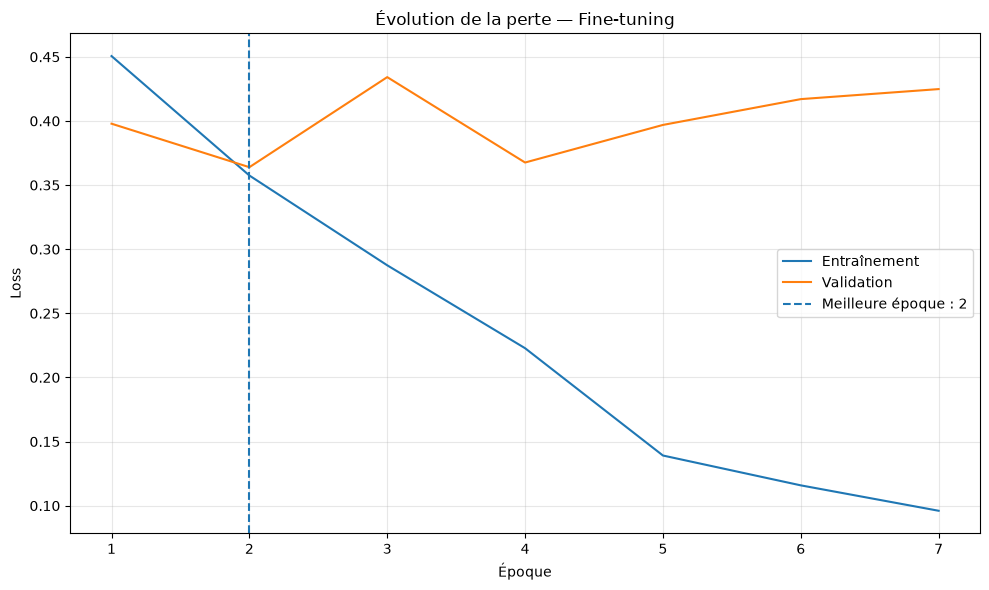

In [65]:
# Courbes de la phase 2

plt.figure(figsize=(10, 6))

plt.plot(
    history_phase2_df.index,
    history_phase2_df["loss"],
    label="Entraînement"
)

plt.plot(
    history_phase2_df.index,
    history_phase2_df["val_loss"],
    label="Validation"
)

plt.axvline(
    best_epoch_phase2,
    linestyle="--",
    label=f"Meilleure époque : {best_epoch_phase2}"
)

plt.title("Évolution de la perte — Fine-tuning")
plt.xlabel("Époque")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

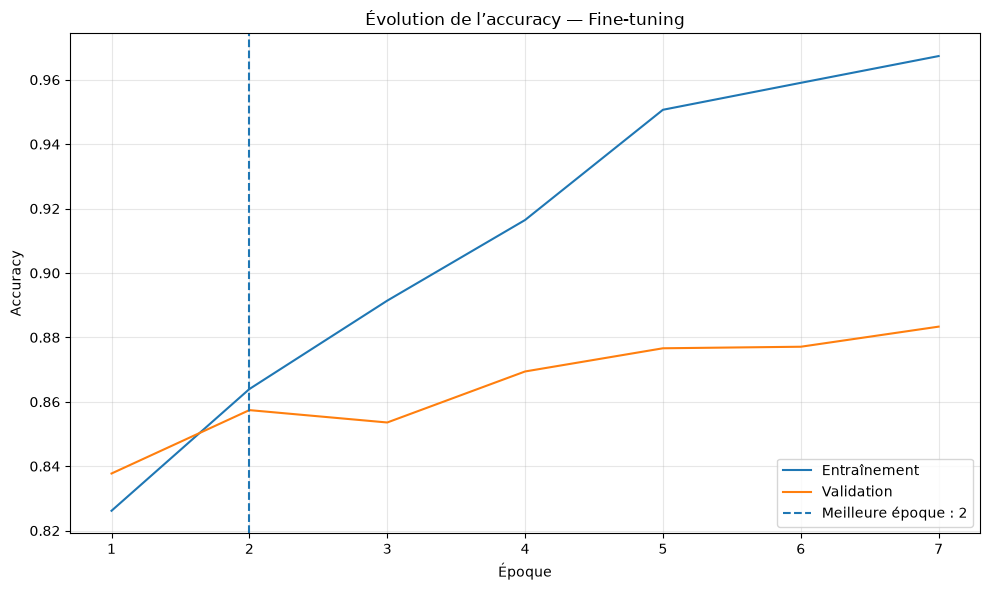

In [66]:
# Courbes de la phase 2

plt.figure(figsize=(10, 6))

plt.plot(
    history_phase2_df.index,
    history_phase2_df["accuracy"],
    label="Entraînement"
)

plt.plot(
    history_phase2_df.index,
    history_phase2_df["val_accuracy"],
    label="Validation"
)

plt.axvline(
    best_epoch_phase2,
    linestyle="--",
    label=f"Meilleure époque : {best_epoch_phase2}"
)

plt.title("Évolution de l’accuracy — Fine-tuning")
plt.xlabel("Époque")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Évaluation finale du modèle fine-tuné

Le meilleur modèle obtenu pendant le fine-tuning est chargé depuis le fichier
de sauvegarde.

L’évaluation est ensuite réalisée sur le jeu de test indépendant, qui n’a pas
été utilisé pour entraîner le modèle ni pour sélectionner la meilleure époque.

In [67]:
# Chargement du meilleur modèle après fine-tuning

best_model_phase2 = keras.models.load_model(
    PHASE2_MODEL_PATH
)

print("Meilleur modèle fine-tuné chargé.")
print("Chemin :", PHASE2_MODEL_PATH)

Meilleur modèle fine-tuné chargé.
Chemin : /mnt/c/Users/n_a_e/Documents/DataScientest/Data Scientist/Projet COVID/Liora_Covid/notebooks/Modelisation/ResNet/outputs_resnet50_sans_class_weight/resnet50_finetuning_best.keras


In [68]:
# Vérification rapide avec evaluate
# Cette première évaluation fournit la perte et l’accuracy, mais nous allons ensuite calculer toutes les métriques détaillées.

test_loss_phase2, test_accuracy_phase2 = (
    best_model_phase2.evaluate(
        test_ds,
        verbose=1
    )
)

print("\nÉvaluation Keras sur le test :")
print(f"Test loss     : {test_loss_phase2:.4f}")
print(f"Test accuracy : {test_accuracy_phase2:.4f}")

66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.8589 - loss: 0.3783

Évaluation Keras sur le test :
Test loss     : 0.3783
Test accuracy : 0.8589


In [69]:
# Génération des prédictions

y_true_phase2 = []
y_pred_phase2 = []
y_prob_phase2 = []

for images, labels in test_ds:

    probabilities = best_model_phase2.predict(
        images,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    y_true_phase2.extend(labels.numpy())
    y_pred_phase2.extend(predictions)
    y_prob_phase2.extend(probabilities)

y_true_phase2 = np.array(y_true_phase2)
y_pred_phase2 = np.array(y_pred_phase2)
y_prob_phase2 = np.array(y_prob_phase2)

print("Nombre d'images évaluées :", len(y_true_phase2))
print("Forme des probabilités :", y_prob_phase2.shape)

Nombre d'images évaluées : 2084
Forme des probabilités : (2084, 4)


In [70]:
# Calcul des métriques finales

accuracy_phase2 = accuracy_score(
    y_true_phase2,
    y_pred_phase2
)

balanced_accuracy_phase2 = balanced_accuracy_score(
    y_true_phase2,
    y_pred_phase2
)

precision_phase2 = precision_score(
    y_true_phase2,
    y_pred_phase2,
    average="macro",
    zero_division=0
)

recall_phase2 = recall_score(
    y_true_phase2,
    y_pred_phase2,
    average="macro",
    zero_division=0
)

f1_phase2 = f1_score(
    y_true_phase2,
    y_pred_phase2,
    average="macro",
    zero_division=0
)

results_phase2 = pd.DataFrame({
    "Métrique": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision macro",
        "Recall macro",
        "F1 macro"
    ],
    "Valeur": [
        accuracy_phase2,
        balanced_accuracy_phase2,
        precision_phase2,
        recall_phase2,
        f1_phase2
    ]
})

results_phase2

,Métrique,Valeur
0,Accuracy,0.858925
1,Balanced Accuracy,0.861269
2,Precision macro,0.852806
3,Recall macro,0.861269
4,F1 macro,0.855494


In [71]:
# Rapport de classification
print("Rapport phase_2")
print(
    classification_report(
        y_true_phase2,
        y_pred_phase2,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

Rapport phase_2
                 precision    recall  f1-score   support

          COVID     0.7120    0.8071    0.7566       337
   Lung_Opacity     0.8776    0.7780    0.8248       599
         Normal     0.8946    0.9122    0.9033      1014
Viral Pneumonia     0.9270    0.9478    0.9373       134

       accuracy                         0.8589      2084
      macro avg     0.8528    0.8613    0.8555      2084
   weighted avg     0.8623    0.8589    0.8592      2084



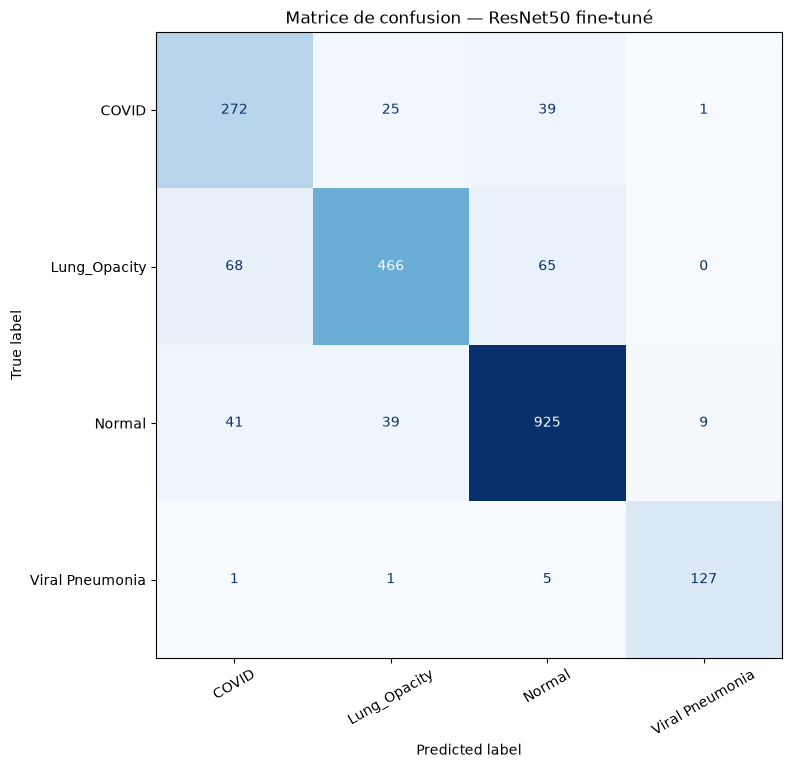

In [72]:
# Matrice de confusion

cm_phase2 = confusion_matrix(
    y_true_phase2,
    y_pred_phase2
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_phase2,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))

disp.plot(
    ax=ax,
    colorbar=False,
    cmap="Blues"
)

plt.title("Matrice de confusion — ResNet50 fine-tuné")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Interprétabilité du modèle avec Grad-CAM

Grad-CAM permet de visualiser les régions de l’image ayant le plus contribué
à la prédiction du modèle.

La carte d’activation est calculée à partir de la dernière sortie
convolutionnelle de ResNet50, puis superposée à la radiographie originale.

In [73]:
# Vérifier la couche utilisée

resnet_base = best_model_phase2.get_layer("resnet50")

print("Nom du modèle de base :", resnet_base.name)
print("Forme de sa sortie    :", resnet_base.output_shape)
print("Dernière couche       :", resnet_base.layers[-1].name)

Nom du modèle de base : resnet50
Forme de sa sortie    : (None, 7, 7, 2048)
Dernière couche       : conv5_block3_out


In [74]:
# Fonction de restauration de l’image

def deprocess_resnet50(image):
    """
    Restaure une image prétraitée avec
    tf.keras.applications.resnet50.preprocess_input
    afin de pouvoir l'afficher en RGB.
    """
    image = image.numpy().copy()

    # Réintégration des moyennes ImageNet en ordre BGR
    image[..., 0] += 103.939
    image[..., 1] += 116.779
    image[..., 2] += 123.680

    # Conversion BGR vers RGB
    image = image[..., ::-1]

    return np.clip(image, 0, 255).astype("uint8")

In [75]:
# Construction des deux sous-modèles nécessaires pour Grad-CAM

# Modèle ResNet50 imbriqué dans le modèle complet
resnet_base = best_model_phase2.get_layer("resnet50")

# Dernière couche convolutionnelle de ResNet50
LAST_CONV_LAYER_NAME = "conv5_block3_out"

last_conv_layer = resnet_base.get_layer(
    LAST_CONV_LAYER_NAME
)

# Sous-modèle :
# image -> dernière carte convolutionnelle + sortie finale de ResNet50
conv_model = keras.Model(
    inputs=resnet_base.inputs,
    outputs=[
        last_conv_layer.output,
        resnet_base.output
    ],
    name="resnet50_gradcam"
)

print("Couche Grad-CAM :", last_conv_layer.name)
print("Sortie convolutionnelle :", last_conv_layer.output.shape)
print("Sortie ResNet50 :", resnet_base.output.shape)

Couche Grad-CAM : conv5_block3_out
Sortie convolutionnelle : (None, 7, 7, 2048)
Sortie ResNet50 : (None, 7, 7, 2048)


In [76]:
# Construction des deux sous-modèles nécessaires pour Grad-CAM

# Entrée correspondant à la sortie de ResNet50
classifier_input = keras.Input(
    shape=resnet_base.output_shape[1:],
    name="classifier_input"
)

x = classifier_input

# Application des couches situées après ResNet50
resnet_layer_index = best_model_phase2.layers.index(
    resnet_base
)

for layer in best_model_phase2.layers[
    resnet_layer_index + 1:
]:
    x = layer(x)

classifier_model = keras.Model(
    inputs=classifier_input,
    outputs=x,
    name="classification_head"
)

classifier_model.summary()

Model: "classification_head"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ classifier_input (InputLayer)   │ (None, 7, 7, 2048)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification (Dense)          │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,196 (32.02 KB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 0 (0.00 B)

In [77]:
# fonction Grad-CAM

def make_gradcam_heatmap(
    image_batch,
    conv_model,
    classifier_model,
    class_index=None
):
    """
    Calcule une carte Grad-CAM pour le modèle ResNet50 imbriqué.
    """

    with tf.GradientTape() as tape:

        # Cartes convolutives et sortie finale du ResNet50
        conv_outputs, resnet_features = conv_model(
            image_batch,
            training=False
        )

        # Nécessaire pour calculer le gradient par rapport aux activations
        tape.watch(conv_outputs)

        # Passage dans la tête de classification
        predictions = classifier_model(
            resnet_features,
            training=False
        )

        if class_index is None:
            class_index = tf.argmax(
                predictions[0]
            )

        class_score = predictions[
            :,
            class_index
        ]

    gradients = tape.gradient(
        class_score,
        conv_outputs
    )

    if gradients is None:
        raise RuntimeError(
            "Les gradients n'ont pas pu être calculés."
        )

    # Importance moyenne de chaque canal
    channel_weights = tf.reduce_mean(
        gradients,
        axis=(0, 1, 2)
    )

    feature_maps = conv_outputs[0]

    # Somme pondérée des cartes d'activation
    heatmap = tf.reduce_sum(
        feature_maps * channel_weights,
        axis=-1
    )

    # Grad-CAM conserve les contributions positives
    heatmap = tf.nn.relu(heatmap)

    # Normalisation entre 0 et 1
    max_value = tf.reduce_max(heatmap)

    if max_value > 0:
        heatmap = heatmap / max_value

    return (
        heatmap.numpy(),
        predictions[0].numpy(),
        int(class_index.numpy())
    )

In [78]:
# Fonction de superposition

def overlay_gradcam(
    original_image,
    heatmap,
    alpha=0.4
):
    """
    Superpose une carte Grad-CAM à l'image originale.
    """

    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        size=original_image.shape[:2]
    ).numpy().squeeze()

    # Transformation de la heatmap en image colorée
    colored_heatmap = plt.get_cmap("jet")(
        heatmap_resized
    )[..., :3]

    colored_heatmap = (
        colored_heatmap * 255
    ).astype("uint8")

    superimposed_image = (
        (1 - alpha) * original_image
        + alpha * colored_heatmap
    )

    return np.clip(
        superimposed_image,
        0,
        255
    ).astype("uint8")

In [79]:
def display_gradcam_grid(
    dataset,
    model,
    conv_model,
    classifier_model,
    class_names,
    n_images=12,
    only_errors=False
):
    """
    Affiche plusieurs images avec leur Grad-CAM.

    Parameters
    ----------
    dataset : tf.data.Dataset
        Dataset prétraité pour ResNet50.
    model : keras.Model
        Modèle complet fine-tuné.
    conv_model : keras.Model
        Sous-modèle fournissant les activations convolutionnelles.
    classifier_model : keras.Model
        Tête de classification.
    class_names : list[str]
        Noms des classes.
    n_images : int
        Nombre maximal d'images à afficher.
    only_errors : bool
        Si True, affiche uniquement les prédictions incorrectes.
    """

    selected = []

    for images_batch, labels_batch in dataset:

        probabilities_batch = model.predict(
            images_batch,
            verbose=0
        )

        predictions_batch = np.argmax(
            probabilities_batch,
            axis=1
        )

        for image_tensor, true_label, pred_label, probabilities in zip(
            images_batch,
            labels_batch.numpy(),
            predictions_batch,
            probabilities_batch
        ):
            is_error = int(true_label) != int(pred_label)

            if only_errors and not is_error:
                continue

            selected.append({
                "image_tensor": image_tensor,
                "true_label": int(true_label),
                "pred_label": int(pred_label),
                "probabilities": probabilities
            })

            if len(selected) >= n_images:
                break

        if len(selected) >= n_images:
            break

    if not selected:
        print("Aucune image correspondant au critère.")
        return

    fig, axes = plt.subplots(
        len(selected),
        2,
        figsize=(10, 4 * len(selected))
    )

    if len(selected) == 1:
        axes = np.array([axes])

    for row, item in enumerate(selected):

        image_tensor = item["image_tensor"]
        true_label = item["true_label"]
        pred_label = item["pred_label"]
        probabilities = item["probabilities"]

        image_batch = tf.expand_dims(
            image_tensor,
            axis=0
        )

        heatmap, _, predicted_class_index = (
            make_gradcam_heatmap(
                image_batch=image_batch,
                conv_model=conv_model,
                classifier_model=classifier_model
            )
        )

        original_image = deprocess_resnet50(
            image_tensor
        )

        gradcam_image = overlay_gradcam(
            original_image,
            heatmap,
            alpha=0.4
        )

        confidence = float(
            probabilities[predicted_class_index]
        )

        true_name = class_names[true_label]
        pred_name = class_names[pred_label]

        status = (
            "Correct"
            if true_label == pred_label
            else "Erreur"
        )

        axes[row, 0].imshow(original_image)
        axes[row, 0].set_title(
            f"Image originale\n"
            f"Classe réelle : {true_name}"
        )
        axes[row, 0].axis("off")

        axes[row, 1].imshow(gradcam_image)
        axes[row, 1].set_title(
            f"{status}\n"
            f"Prédiction : {pred_name}\n"
            f"Confiance : {confidence:.1%}"
        )
        axes[row, 1].axis("off")

    plt.tight_layout()
    plt.show()

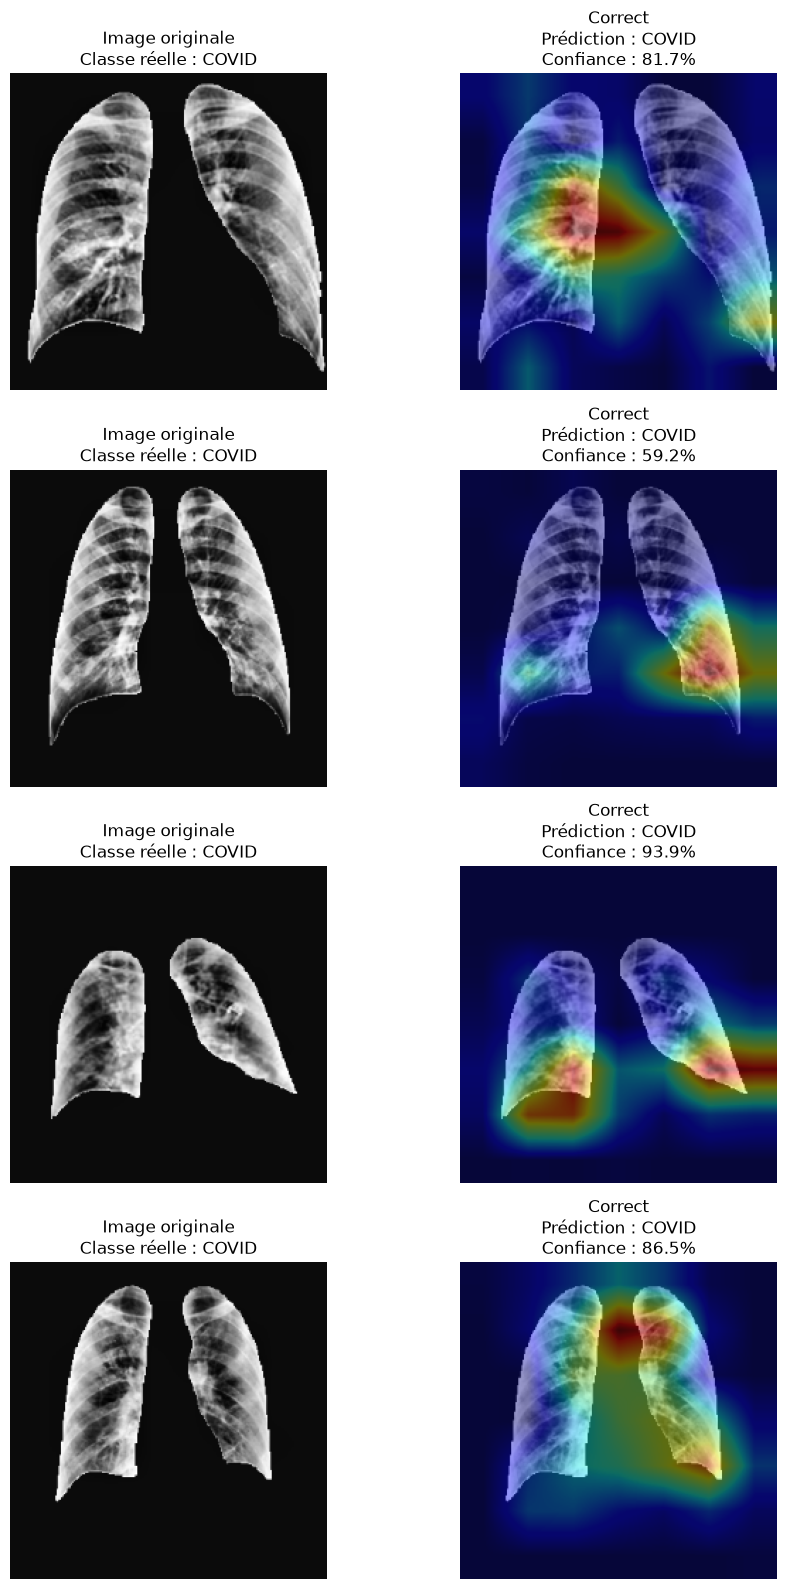

In [80]:
display_gradcam_grid(
    dataset=test_ds,
    model=best_model_phase2,
    conv_model=conv_model,
    classifier_model=classifier_model,
    class_names=class_names,
    n_images=4,
    only_errors=False
)

# Conclusion

## Synthèse

Cette section rassemble l'ensemble des résultats obtenus avec le modèle
fine-tuné.

Les performances sont évaluées à l'aide de plusieurs métriques adaptées
à un problème de classification multiclasse déséquilibré :

- Accuracy
- Balanced Accuracy
- Precision macro
- Recall macro
- F1-score macro

Les résultats sont ensuite comparés à ceux obtenus avant le fine-tuning.

In [81]:
# Tableau comparatif Phase 1 / Phase 2

comparison_results = pd.DataFrame({
    "Métrique": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision macro",
        "Recall macro",
        "F1 macro"
    ],

    "Phase 1": [
        accuracy,
        balanced_accuracy,
        precision,
        recall,
        f1
    ],

    "Fine-tuning": [
        accuracy_phase2,
        balanced_accuracy_phase2,
        precision_phase2,
        recall_phase2,
        f1_phase2
    ]
})

comparison_results["Gain"] = (
    comparison_results["Fine-tuning"]
    - comparison_results["Phase 1"]
)

comparison_results

,Métrique,Phase 1,Fine-tuning,Gain
0,Accuracy,0.818618,0.858925,0.040307
1,Balanced Accuracy,0.793539,0.861269,0.067729
2,Precision macro,0.817244,0.852806,0.035562
3,Recall macro,0.793539,0.861269,0.067729
4,F1 macro,0.803245,0.855494,0.052249


In [82]:
# Tableau formaté en %

comparison_display = comparison_results.copy()

for col in ["Phase 1", "Fine-tuning", "Gain"]:
    comparison_display[col] = (
        comparison_display[col] * 100
    ).map(lambda x: f"{x:.2f} %")

comparison_display

,Métrique,Phase 1,Fine-tuning,Gain
0,Accuracy,81.86 %,85.89 %,4.03 %
1,Balanced Accuracy,79.35 %,86.13 %,6.77 %
2,Precision macro,81.72 %,85.28 %,3.56 %
3,Recall macro,79.35 %,86.13 %,6.77 %
4,F1 macro,80.32 %,85.55 %,5.22 %


## Bénéfice du Fine Tuning

Cette dernière section résume automatiquement les performances obtenues et
l'apport du fine-tuning.

Les conclusions sont calculées directement à partir des résultats du modèle.

In [83]:
gain_accuracy = (
    accuracy_phase2 - accuracy
) * 100

gain_f1 = (
    f1_phase2 - f1
) * 100

gain_balanced = (
    balanced_accuracy_phase2
    - balanced_accuracy
) * 100

print("=" * 70)
print("CONCLUSION DU PROJET")
print("=" * 70)

print()

print(
    f"Accuracy            : {accuracy_phase2:.4f}"
)

print(
    f"Balanced Accuracy   : {balanced_accuracy_phase2:.4f}"
)

print(
    f"F1-score macro      : {f1_phase2:.4f}"
)

print()

print("Apport du fine-tuning")

print(
    f"Accuracy       : +{gain_accuracy:.2f} points"
)

print(
    f"Balanced Acc.  : +{gain_balanced:.2f} points"
)

print(
    f"F1 macro       : +{gain_f1:.2f} points"
)

print()

print(
    "Le modèle final retenu est le modèle "
    "fine-tuné sauvegardé après EarlyStopping."
)

print("=" * 70)

CONCLUSION DU PROJET

Accuracy            : 0.8589
Balanced Accuracy   : 0.8613
F1-score macro      : 0.8555

Apport du fine-tuning
Accuracy       : +4.03 points
Balanced Acc.  : +6.77 points
F1 macro       : +5.22 points

Le modèle final retenu est le modèle fine-tuné sauvegardé après EarlyStopping.
